# Import Section

In [1]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import torch

from collections import Counter
from torch.utils.data import DataLoader
from dataclasses import dataclass
from typing import List, Dict, Any
from transformers import Wav2Vec2Processor
from tqdm import tqdm
from datasets import load_dataset, Audio
from transformers import Wav2Vec2ForCTC
from transformers import Wav2Vec2Model
from sklearn.utils.class_weight import compute_class_weight


!pip install transformers torchaudio -q

#Member 1: Data + Preprocessing

In [2]:
!pip install datasets torchaudio -q

In [3]:
# SEEDING
SEED = 42
random.seed(SEED)

np.random.seed(SEED)
torch.manual_seed(SEED)


In [4]:
# LOAD DATASET
dataset = load_dataset("mteb/speech-commands-mini")

print(dataset)
print(dataset["train"][0])

labels = dataset["train"].features["label"].names
print("Labels:", labels)
print("Number of classes:", len(labels))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/61.9M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/292M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/143M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1755 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/9982 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4890 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 1755
    })
    validation: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 9982
    })
    test: Dataset({
        features: ['file', 'audio', 'label', 'is_unknown', 'speaker_id', 'utterance_id'],
        num_rows: 4890
    })
})
{'file': 'backward/1e9e6bdd_nohash_2.wav', 'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7b1b7f89a720>, 'label': 30, 'is_unknown': True, 'speaker_id': '1e9e6bdd', 'utterance_id': 2}
Labels: ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go', 'zero', 'one', 'two', 'three', 'four', 'five', 'six', 'seven', 'eight', 'nine', 'bed', 'bird', 'cat', 'dog', 'happy', 'house', 'marvin', 'sheila', 'tree', 'wow', 'backward', 'forward', 'follow', 'learn', 'visual', '_silence_']
Number of classes: 36


In [5]:
selected_labels = list(range(10))

def filter_labels(example):
  return example["label"] in selected_labels

dataset = dataset.filter(filter_labels)

Filter:   0%|          | 0/1755 [00:00<?, ? examples/s]

Filter:   0%|          | 0/9982 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4890 [00:00<?, ? examples/s]

In [19]:
print("Selected classes:")
for i in selected_labels:
    print(i, labels[i])

Selected classes:
0 yes
1 no
2 up
3 down
4 left
5 right
6 on
7 off
8 stop
9 go


In [6]:
# SPLIT DATASET
dataset = dataset["train"].train_test_split(test_size=0.2, seed=42)
temp = dataset["test"].train_test_split(test_size=0.5, seed=42)

dataset = {
    "train": dataset["train"],
    "validation": temp["train"],
    "test": temp["test"]
}

for split in dataset:
    print(split, len(dataset[split]))

train 400
validation 50
test 50


In [7]:
# CAST AUDIO
dataset = {
    split: dataset[split].cast_column("audio", Audio(sampling_rate=16000))
    for split in dataset
}

In [9]:
# PREPROCESSING
def preprocess(example):
    audio = example["audio"]["array"].astype(np.float32)

    max_val = np.max(np.abs(audio))
    if max_val > 0:
        audio = audio / max_val

    example["input_values"] = audio
    example["length"] = len(audio)

    return example

dataset = {
    split: dataset[split].map(preprocess)
    for split in dataset
}

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [10]:
# ===== FIX 6: CLASS WEIGHTS =====
train_labels = [x["label"] for x in dataset["train"]]

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = torch.tensor(class_weights, dtype=torch.float)

In [11]:
# CHECK DISTRIBUTION
train_labels = [x["label"] for x in dataset["train"]]
val_labels = [x["label"] for x in dataset["validation"]]

print("Train:", Counter(train_labels))
print("Val:", Counter(val_labels))

Train: Counter({3: 43, 2: 43, 5: 42, 6: 42, 7: 41, 8: 41, 9: 39, 4: 38, 0: 36, 1: 35})
Val: Counter({1: 8, 9: 7, 5: 6, 4: 6, 0: 6, 6: 5, 7: 4, 8: 4, 3: 3, 2: 1})


#Member 2: Feature Engineering + wav2vec Input

In [12]:
# PROCESSOR (MEMBER 2)
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
print("Processor loaded")

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

Processor loaded


In [13]:
# FEATURE EXTRACTION
def wav2vec_feature_extraction(batch):
    return {
        "input_values": batch["input_values"],
        "label": batch["label"]
    }


dataset = {
    split: dataset[split].map(
        wav2vec_feature_extraction,
        batched=True,
        batch_size=8
    )
    for split in dataset
}

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [14]:
dataset = {
    split: dataset[split].remove_columns(
        [col for col in dataset[split].column_names if col not in ["input_values", "label"]]
    )
    for split in dataset
}

In [15]:
# COLLATOR
@dataclass
class DataCollatorSpeech:
    processor: Wav2Vec2Processor

    def __call__(self, features: List[Dict[str, Any]]):

        audio = [f["input_values"] for f in features]
        labels = torch.tensor([f["label"] for f in features])

        batch = self.processor(
            audio,
            sampling_rate=16000,
            padding=True,
            return_tensors="pt",
            return_attention_mask=True
        )

        batch["labels"] = labels
        return batch


collator = DataCollatorSpeech(processor)

In [16]:
# DATALOADERS
train_loader = DataLoader(
    dataset["train"],
    batch_size=8,
    shuffle=True,
    collate_fn=collator,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    dataset["validation"],
    batch_size=8,
    shuffle=False,
    collate_fn=collator
)

test_loader = DataLoader(
    dataset["test"],
    batch_size=8,
    shuffle=False,
    collate_fn=collator
)

print("DataLoaders ready")

DataLoaders ready


In [17]:
# TEST BATCH
batch = next(iter(train_loader))

print("Input shape:", batch["input_values"].shape)
print("Labels shape:", batch["labels"].shape)
print("Attention shape:", batch["attention_mask"].shape)

print("PIPELINE READY ")

Input shape: torch.Size([8, 16000])
Labels shape: torch.Size([8])
Attention shape: torch.Size([8, 16000])
PIPELINE READY 


In [18]:
# FINAL SANITY CHECK
batch = next(iter(train_loader))

print("Input shape:", batch["input_values"].shape)
print("Labels shape:", batch["labels"].shape)
print("Attention shape:", batch["attention_mask"].shape)

assert batch["input_values"].dtype == torch.float32
assert batch["labels"].dtype == torch.long

print("PIPELINE FULLY READY FOR TRAINING ")

Input shape: torch.Size([8, 16000])
Labels shape: torch.Size([8])
Attention shape: torch.Size([8, 16000])
PIPELINE FULLY READY FOR TRAINING 


#Member 3: Baseline Model


In [20]:
def masked_mean_pool(hidden_states, attention_mask):
    mask = attention_mask.unsqueeze(-1).type_as(hidden_states)
    hidden = hidden_states * mask
    summed = hidden.sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts

In [21]:
class Wav2VecClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        # pretrained encoder
        self.wav2vec = Wav2Vec2Model.from_pretrained(
            "facebook/wav2vec2-base"
        )

        # freeze feature extractor (keeps stability)
        for param in self.wav2vec.feature_extractor.parameters():
            param.requires_grad = False

        # unfreeze last transformer layers (fine-tuning)
        for param in self.wav2vec.encoder.layers[-2:].parameters():
            param.requires_grad = True

        # classification head
        self.classifier = nn.Linear(768, num_classes)

    def forward(self, input_values, attention_mask=None):

        outputs = self.wav2vec(
            input_values=input_values,
            attention_mask=attention_mask
        )

        hidden_states = outputs.last_hidden_state  # (B, T_hidden, 768)

        # Create an attention mask for the hidden states (feature vectors)
        # by checking for non-zero activations, as padding often results in zeros.
        feature_attention_mask = (hidden_states.abs().sum(dim=-1) != 0).float()

        # attention pooling (better than mean pooling)
        weights = torch.softmax(hidden_states.mean(dim=-1), dim=1).unsqueeze(-1)
        pooled = torch.sum(hidden_states * weights, dim=1)

        logits = self.classifier(pooled)

        return logits

In [22]:
def build_model(num_classes=10):
    return Wav2VecClassifier(num_classes=num_classes)

# Member 4: Time Mask Augmentation - inspired by SpecAugment

In [23]:
def waveform_time_mask(x, p=0.8, num_time_masks=2, max_mask_ratio=0.1):


    if torch.rand(1).item() > p:
        return x

    B, T = x.shape
    x = x.clone()

    for b in range(B):
        for _ in range(num_time_masks):

            # mask length (up to 10% of signal)
            t = int(T * max_mask_ratio * torch.rand(1).item())

            if t == 0:
                continue

            # start position
            t0 = torch.randint(0, max(1, T - t), (1,)).item()
            x[b, t0:t0 + t] = 0



    return x

In [24]:
def time_mask_features(x, p=0.8, max_mask_len=50):
    if torch.rand(1).item() > p:
        return x

    B, T, D = x.shape
    x = x.clone()

    for b in range(B):
        for _ in range(2):
            t = torch.randint(0, max_mask_len, (1,)).item()
            t0 = torch.randint(0, max(1, T - t), (1,)).item()
            x[b, t0:t0 + t, :] = 0

    return x


# Member 5: Training Pipeline + Experiment Runner


In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
# ensure reproducibility (important for report)
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [27]:
class_weights = class_weights.to(device)

In [28]:
baseline_model = build_model(num_classes=10).to(device)
augmented_model = build_model(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [29]:
baseline_optimizer = optim.AdamW(baseline_model.parameters(), lr=3e-5)
augmented_optimizer = optim.AdamW(augmented_model.parameters(), lr=3e-5)


In [30]:
def train_one_epoch_baseline(model, optimizer, loader):
    model.train()
    total_loss = 0

    for batch in loader:
        x = batch["input_values"].to(device)
        y = batch["labels"].to(device)
        attention = batch["attention_mask"].to(device)

        optimizer.zero_grad()

        logits = model(x, attention_mask=attention)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [32]:
def train_one_epoch_augmented(model, optimizer, loader):
    model.train()
    total_loss = 0

    for batch in loader:
        x = batch["input_values"].to(device)
        y = batch["labels"].to(device)
        attention = batch["attention_mask"].to(device)

        optimizer.zero_grad()

        # forward through wav2vec2
        outputs = model.wav2vec(
            input_values=x,
            attention_mask=attention
        )

        hidden_states = outputs.last_hidden_state

        # augmentation (correct)
        hidden_states = time_mask_features(hidden_states)

        # pooling + classification
        pooled = torch.mean(hidden_states, dim=1)
        logits = model.classifier(pooled)

        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [33]:
def evaluate(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            x = batch["input_values"].to(device)
            y = batch["labels"].to(device)
            attention = batch["attention_mask"].to(device)

            logits = model(x, attention_mask=attention)
            preds = torch.argmax(logits, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [34]:
epochs = 15
print("=== EXPERIMENT 1: BASELINE ===")

for epoch in range(epochs):
    loss = train_one_epoch_baseline(baseline_model, baseline_optimizer, train_loader)
    val_acc = evaluate(baseline_model, val_loader)

    print(f"[Baseline] Epoch {epoch+1} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f}")

=== EXPERIMENT 1: BASELINE ===
[Baseline] Epoch 1 | Loss: 2.2111 | Val Acc: 0.5400
[Baseline] Epoch 2 | Loss: 1.2830 | Val Acc: 0.8600
[Baseline] Epoch 3 | Loss: 0.7159 | Val Acc: 0.9000
[Baseline] Epoch 4 | Loss: 0.5396 | Val Acc: 0.8000
[Baseline] Epoch 5 | Loss: 0.5479 | Val Acc: 0.8800
[Baseline] Epoch 6 | Loss: 0.3914 | Val Acc: 0.8200
[Baseline] Epoch 7 | Loss: 0.4013 | Val Acc: 0.9000
[Baseline] Epoch 8 | Loss: 0.4302 | Val Acc: 0.8600
[Baseline] Epoch 9 | Loss: 0.3423 | Val Acc: 0.8400
[Baseline] Epoch 10 | Loss: 0.3237 | Val Acc: 0.9200
[Baseline] Epoch 11 | Loss: 0.1962 | Val Acc: 0.8600
[Baseline] Epoch 12 | Loss: 0.3252 | Val Acc: 0.8600
[Baseline] Epoch 13 | Loss: 0.3862 | Val Acc: 0.8800
[Baseline] Epoch 14 | Loss: 0.4055 | Val Acc: 0.8600
[Baseline] Epoch 15 | Loss: 0.4102 | Val Acc: 0.9000


In [35]:
print("\n=== EXPERIMENT 2: AUGMENTED ===")

for epoch in range(epochs):
    loss = train_one_epoch_augmented(augmented_model, augmented_optimizer, train_loader)
    val_acc = evaluate(augmented_model, val_loader)

    print(f"[Augmented] Epoch {epoch+1} | Loss: {loss:.4f} | Val Acc: {val_acc:.4f}")


=== EXPERIMENT 2: AUGMENTED ===
[Augmented] Epoch 1 | Loss: 2.2850 | Val Acc: 0.1200
[Augmented] Epoch 2 | Loss: 2.0719 | Val Acc: 0.8400
[Augmented] Epoch 3 | Loss: 1.6836 | Val Acc: 0.8600
[Augmented] Epoch 4 | Loss: 1.3785 | Val Acc: 0.8200
[Augmented] Epoch 5 | Loss: 1.3760 | Val Acc: 0.9000
[Augmented] Epoch 6 | Loss: 1.2451 | Val Acc: 0.8400
[Augmented] Epoch 7 | Loss: 1.1758 | Val Acc: 0.8600
[Augmented] Epoch 8 | Loss: 1.2183 | Val Acc: 0.8600
[Augmented] Epoch 9 | Loss: 1.2256 | Val Acc: 0.8800
[Augmented] Epoch 10 | Loss: 1.2262 | Val Acc: 0.7800
[Augmented] Epoch 11 | Loss: 1.0183 | Val Acc: 0.8400
[Augmented] Epoch 12 | Loss: 1.1413 | Val Acc: 0.8600
[Augmented] Epoch 13 | Loss: 1.1122 | Val Acc: 0.8600
[Augmented] Epoch 14 | Loss: 1.1342 | Val Acc: 0.8800
[Augmented] Epoch 15 | Loss: 1.1594 | Val Acc: 0.8800


In [36]:
baseline_test_acc = evaluate(baseline_model, test_loader)
aug_test_acc = evaluate(augmented_model, test_loader)

print("=== FINAL COMPARISON ===")
print("Baseline Test Accuracy:", baseline_test_acc)
print("Augmented Test Accuracy:", aug_test_acc)
print("Improvement:", aug_test_acc - baseline_test_acc)

improvement = ((aug_test_acc - baseline_test_acc) / baseline_test_acc) * 100
print("Improvement %:", improvement)

=== FINAL COMPARISON ===
Baseline Test Accuracy: 0.98
Augmented Test Accuracy: 0.94
Improvement: -0.040000000000000036
Improvement %: -4.081632653061228


# Member 6 ->  Evaluation + Debug + Metrics
Experiment Analysis


###**Extra imports we will need**

In [37]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

###**Collect predictions from both models**

In [38]:
def get_predictions(model, loader):
    """
    Run the model on all batches and collect:
    - all_preds: what the model predicted
    - all_labels: what the correct answer was
    """
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():  # don't calculate gradients, we're just testing
        for batch in loader:
            x = batch["input_values"].to(device)
            y = batch["labels"].to(device)
            attention = batch["attention_mask"].to(device)

            logits = model(x, attention_mask=attention)
            preds = torch.argmax(logits, dim=1)  # pick the class with highest score

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    return np.array(all_preds), np.array(all_labels)

# Run on the test set
baseline_preds, true_labels = get_predictions(baseline_model, test_loader)
augmented_preds, _          = get_predictions(augmented_model, test_loader)

print("Predictions collected!")
print(f"Total test samples: {len(true_labels)}")

Predictions collected!
Total test samples: 50


###**Accuracy comparison table**

In [39]:
baseline_acc  = (baseline_preds  == true_labels).mean()
augmented_acc = (augmented_preds == true_labels).mean()

improvement    = augmented_acc - baseline_acc
improvement_pct = (improvement / baseline_acc+ 1e-9) * 100

print("-" * 45)
print(f"{'Model':<25} {'Accuracy':>10}")
print("-" * 45)
print(f"{'Baseline wav2vec':<25} {baseline_acc:>9.2%}")
print(f"{'wav2vec + SpecAugment':<25} {augmented_acc:>9.2%}")
print("-" * 45)
print(f"\nAbsolute improvement : {improvement:+.2%}")
print(f"Relative improvement : {improvement_pct:+.1f}%")

if improvement > 0:
    print("\n SpecAugment HELPED")
elif improvement == 0:
    print("\n  No change.")
else:
    print("\n SpecAugment HURT performance on this run")

---------------------------------------------
Model                       Accuracy
---------------------------------------------
Baseline wav2vec             98.00%
wav2vec + SpecAugment        94.00%
---------------------------------------------

Absolute improvement : -4.00%
Relative improvement : -4.1%

 SpecAugment HURT performance on this run


###**Per-class report (which words were hardest?)**

In [40]:
# Class names from the dataset
class_names = [labels[i] for i in range(10)]

print("BASELINE — Per-class Report ")
print(classification_report(true_labels, baseline_preds, target_names=class_names))

print(" AUGMENTED — Per-class Report ")
print(classification_report(true_labels, augmented_preds, target_names=class_names))

BASELINE — Per-class Report 
              precision    recall  f1-score   support

         yes       1.00      0.88      0.93         8
          no       1.00      1.00      1.00         7
          up       1.00      1.00      1.00         6
        down       0.80      1.00      0.89         4
        left       1.00      1.00      1.00         6
       right       1.00      1.00      1.00         2
          on       1.00      1.00      1.00         3
         off       1.00      1.00      1.00         5
        stop       1.00      1.00      1.00         5
          go       1.00      1.00      1.00         4

    accuracy                           0.98        50
   macro avg       0.98      0.99      0.98        50
weighted avg       0.98      0.98      0.98        50

 AUGMENTED — Per-class Report 
              precision    recall  f1-score   support

         yes       1.00      0.88      0.93         8
          no       0.86      0.86      0.86         7
          up      

###**Confusion matrices**

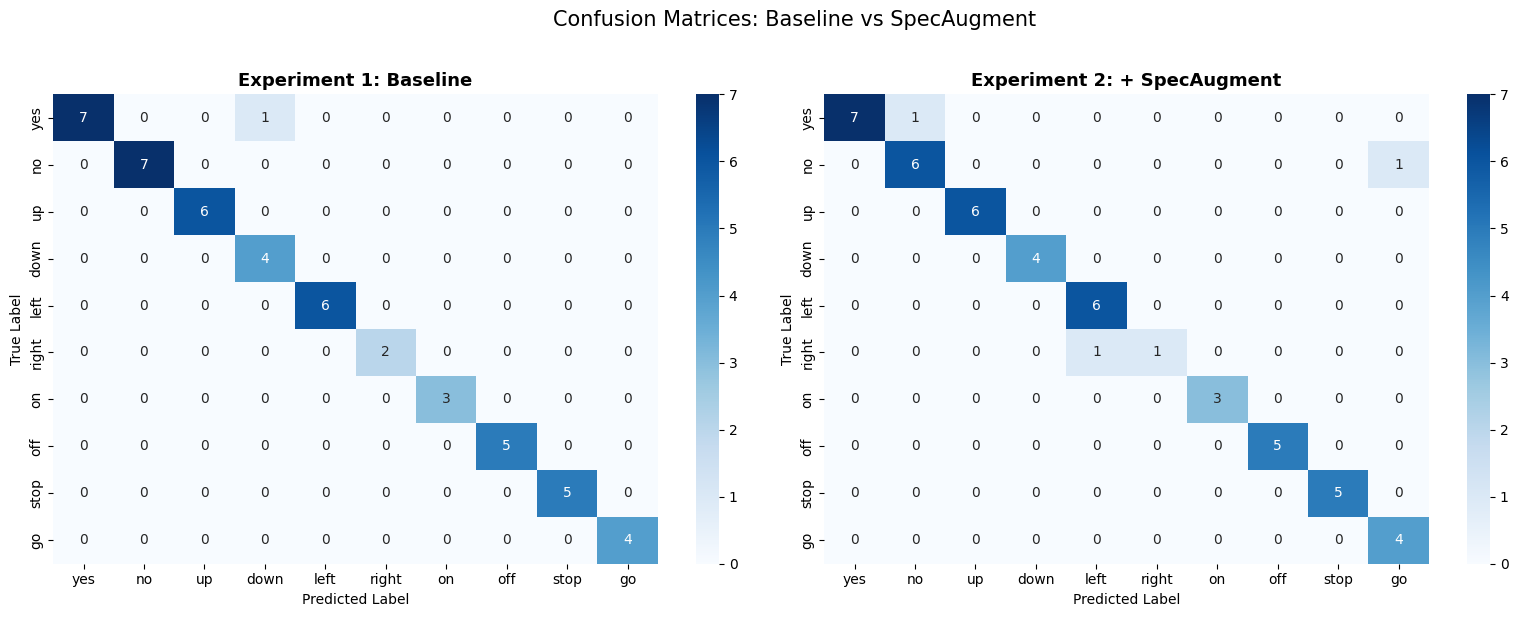

Saved: confusion_matrices.png


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, preds, title in zip(
    axes,
    [baseline_preds, augmented_preds],
    ["Experiment 1: Baseline", "Experiment 2: + SpecAugment"]
):
    cm = confusion_matrix(true_labels, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Confusion Matrices: Baseline vs SpecAugment", fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

###**Error analysis (misclassified examples)**

In [42]:
# Find samples where both models got it wrong, or only one got it wrong
only_baseline_wrong  = (baseline_preds  != true_labels) & (augmented_preds == true_labels)
only_augmented_wrong = (augmented_preds != true_labels) & (baseline_preds  == true_labels)
both_wrong           = (baseline_preds  != true_labels) & (augmented_preds != true_labels)
both_correct         = (baseline_preds  == true_labels) & (augmented_preds == true_labels)

print(" Error Analysis ")
print(f"Both models correct         : {both_correct.sum()} samples")
print(f"Only Baseline wrong (Aug fixed it) : {only_baseline_wrong.sum()} samples ")
print(f"Only Augmented wrong (Aug broke it): {only_augmented_wrong.sum()} samples ")
print(f"Both models wrong           : {both_wrong.sum()} samples")

 Error Analysis 
Both models correct         : 47 samples
Only Baseline wrong (Aug fixed it) : 0 samples 
Only Augmented wrong (Aug broke it): 2 samples 
Both models wrong           : 1 samples


###**Which word classes improved the most?**

In [43]:
print("\n Per-class Accuracy Change (Baseline → Augmented) ")
print(f"{'Class':<12} {'Baseline':>10} {'Augmented':>12} {'Change':>10}")
print("-" * 50)

for i, name in enumerate(class_names):
    mask = (true_labels == i)
    if mask.sum() == 0:
        continue
    base_acc_i = (baseline_preds[mask]  == true_labels[mask]).mean()
    aug_acc_i  = (augmented_preds[mask] == true_labels[mask]).mean()
    delta      = aug_acc_i - base_acc_i
    arrow      = "Improved" if delta > 0.01 else ("Declined" if delta < -0.01 else "Stable")
    print(f"{name:<12} {base_acc_i:>9.1%} {aug_acc_i:>11.1%} {delta:>+9.1%}  {arrow}")


 Per-class Accuracy Change (Baseline → Augmented) 
Class          Baseline    Augmented     Change
--------------------------------------------------
yes              87.5%       87.5%     +0.0%  Stable
no              100.0%       85.7%    -14.3%  Declined
up              100.0%      100.0%     +0.0%  Stable
down            100.0%      100.0%     +0.0%  Stable
left            100.0%      100.0%     +0.0%  Stable
right           100.0%       50.0%    -50.0%  Declined
on              100.0%      100.0%     +0.0%  Stable
off             100.0%      100.0%     +0.0%  Stable
stop            100.0%      100.0%     +0.0%  Stable
go              100.0%      100.0%     +0.0%  Stable


###**Add macro accuracy sanity check**

In [44]:
from sklearn.metrics import accuracy_score

print("Accuracy (sklearn check):", accuracy_score(true_labels, baseline_preds))

Accuracy (sklearn check): 0.98


###**Summary card**

In [45]:
print("\n" + "-" * 50)
print("        FINAL EXPERIMENT SUMMARY")
print("-" * 50)
print(f"  Dataset         : Mini Speech Commands (10 classes)")
print(f"  Baseline Acc    : {baseline_acc:.2%}")
print(f"  Augmented Acc   : {augmented_acc:.2%}")
print(f"  Improvement     : {improvement:+.2%}")
print(f"  Samples fixed   : {only_baseline_wrong.sum()}")
print(f"  Samples broken  : {only_augmented_wrong.sum()}")
print("-" * 50)

conclusion = "SpecAugment improved robustness" if improvement > 0 else "SpecAugment did not improve performance on this run"
print(f"\n  Conclusion: {conclusion}")
print("-" * 50)


--------------------------------------------------
        FINAL EXPERIMENT SUMMARY
--------------------------------------------------
  Dataset         : Mini Speech Commands (10 classes)
  Baseline Acc    : 98.00%
  Augmented Acc   : 94.00%
  Improvement     : -4.00%
  Samples fixed   : 0
  Samples broken  : 2
--------------------------------------------------

  Conclusion: SpecAugment did not improve performance on this run
--------------------------------------------------


In [46]:
torch.save(baseline_model.state_dict(), "baseline_model.pt")

In [47]:
torch.save(augmented_model.state_dict(), "augmented_model.pt")